# Ortam Hazırlanması

In [1]:
# ORTAM KURULUMU
import os
import sys
import gc
import torch
from google.colab import drive

# 1. GPU Bellek Temizliği
gc.collect()
torch.cuda.empty_cache()

# 2. Google Drive Bağlantısı
if not os.path.exists('/content/drive'):
    print("[BİLGİ] Google Drive bağlanıyor...")
    drive.mount('/content/drive')

# 3. Gerekli Kütüphanelerin Kurulumu
print("[BİLGİ] Bağımlılıklar kuruluyor...")
os.system('pip install basicsr -q')
os.system('apt-get install p7zip-full -y -qq')

# 4. HAT Mimarisinin Klonlanması
if not os.path.exists('/content/HAT'):
    print("[BİLGİ] HAT deposu klonlanıyor...")
    os.system('git clone https://github.com/XPixelGroup/HAT.git /content/HAT')

# 5. Sistem Yollarının Tanımlanması
sys.path.append('/content/HAT')
sys.path.append('/content/HAT/hat/archs')

# 6. Registry Çakışması Düzeltmesi
try:
    from basicsr.utils.registry import ARCH_REGISTRY
    if hasattr(ARCH_REGISTRY, '_obj_map'): ARCH_REGISTRY._obj_map.clear()
except: pass

# 7. Donanım Kontrolü
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[SİSTEM] Kullanılan Donanım: {torch.cuda.get_device_name(0)}")

[BİLGİ] Google Drive bağlanıyor...
Mounted at /content/drive
[BİLGİ] Bağımlılıklar kuruluyor...
[BİLGİ] HAT deposu klonlanıyor...
[SİSTEM] Kullanılan Donanım: NVIDIA A100-SXM4-80GB


# Veri setinin hazırlanması

In [2]:
# VERİ SETİ HAZIRLIĞI
import glob
import os

DATASET_ROOT = "/content/dataset"
IMG_FOLDER = os.path.join(DATASET_ROOT, "img")

# Bilinen şifreler listesi
passwords = [
    "mmlab_DeepFashion_inshop",          # In-shop Clothes Retrieval
    "mmlab_DeepFashion_consumer2shop",   # Consumer-to-shop
    "mmlab_DeepFashion_fashionsynth",    # Fashion Synthesis
]

# Veri seti henüz çıkarılmamışsa işlem başlatılır
if not os.path.exists(IMG_FOLDER):
    print("[İŞLEM] Veri seti arşivden çıkarılıyor...")

    # Drive üzerindeki olası zip yolları
    zip_paths = [
        "/content/drive/MyDrive/Görüntü Analizinde Derin Öğrenme Yöntemleri/DeepFashion/Img/img.zip",
        "/content/drive/MyDrive/Görüntü Analizinde Derin Öğrenme Yöntemleri/DeepFashion/Img/img_highres.zip"
    ]

    target_zip = None
    for p in zip_paths:
        if os.path.exists(p):
            target_zip = p
            print(f"[TESPİT] Zip dosyası bulundu: {p}")
            break

    if target_zip:
        os.makedirs(DATASET_ROOT, exist_ok=True)

        success = False
        # Şifre listesindeki her bir şifreyi sırayla dener
        for pwd in passwords:
            print(f"[DENEME] Şifre ile çıkarma deneniyor: {pwd}...")
            # -p bayrağı ile şifre verilir, hata çıktıları gizlenir (> /dev/null)
            exit_code = os.system(f'7z x "{target_zip}" -p"{pwd}" -o"{DATASET_ROOT}" -y > /dev/null 2>&1')

            if exit_code == 0:
                print(f"[BAŞARILI] Doğru şifre bulundu ve arşiv açıldı: {pwd}")
                success = True
                break

        # Eğer hiçbir şifre çalışmazsa, şifresiz deneme yapılır
        if not success:
            print("[UYARI] Şifreler kabul edilmedi, şifresiz deneme yapılıyor...")
            os.system(f'7z x "{target_zip}" -o"{DATASET_ROOT}" -y > /dev/null 2>&1')

        # Çıkarılan dosyaların konumunun doğrulanması ve yolun ayarlanması
        found_jpgs = glob.glob(f"{DATASET_ROOT}/**/*.jpg", recursive=True)
        if found_jpgs:
            # jpg dosyalarının bulunduğu ana dizini bul
            IMG_FOLDER = os.path.dirname(found_jpgs[0])
            # Klasör yapısı 'WOMEN/Blouse/...' şeklindeyse üst dizine çık
            if "WOMEN" in IMG_FOLDER: IMG_FOLDER = IMG_FOLDER.split('/WOMEN')[0]
            elif "MEN" in IMG_FOLDER: IMG_FOLDER = IMG_FOLDER.split('/MEN')[0]
            print(f"[BAŞARILI] Veri seti ana dizini ayarlandı: {IMG_FOLDER}")
        else:
             print("[HATA] Zip çıkarıldı ancak içinde .jpg dosyası bulunamadı.")
    else:
        print("[HATA] Zip dosyası Google Drive yolunda bulunamadı. Lütfen dosya yolunu kontrol ediniz.")
else:
    print("[BİLGİ] Veri seti zaten mevcut, çıkarma işlemi atlanıyor.")

[İŞLEM] Veri seti arşivden çıkarılıyor...
[TESPİT] Zip dosyası bulundu: /content/drive/MyDrive/Görüntü Analizinde Derin Öğrenme Yöntemleri/DeepFashion/Img/img.zip
[DENEME] Şifre ile çıkarma deneniyor: mmlab_DeepFashion_inshop...
[BAŞARILI] Doğru şifre bulundu ve arşiv açıldı: mmlab_DeepFashion_inshop
[BAŞARILI] Veri seti ana dizini ayarlandı: /content/dataset/img


# Veri Yükleme ve Dinamik Leke Maskeleme

In [3]:
# VERİ SETİ AYRIMI (%90 EĞİTİM - %10 TEST) VE LEKE MASKELEME
import random
import glob
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Görüntü Yollarının Toplanması ve Ayrıştırılması
print("[İŞLEM] Veri setindeki tüm görüntüler taranıyor...")
all_image_paths = sorted(glob.glob(os.path.join(IMG_FOLDER, '**', '*.jpg'), recursive=True))

# Veri sayısı kontrolü
total_images = len(all_image_paths)
if total_images == 0:
    raise ValueError(f"[HATA] '{IMG_FOLDER}' konumunda hiç .jpg dosyası bulunamadı. Lütfen Hücre 2'yi kontrol ediniz.")

# Rastgele Karıştırma (Shuffle) - Her seferinde farklı dağılım olmaması için seed sabitlenebilir
random.seed(42)
random.shuffle(all_image_paths)

# %90 Eğitim, %10 Test Ayrımı
split_index = int(total_images * 0.90)
train_paths = all_image_paths[:split_index]
test_paths = all_image_paths[split_index:]

# İstatistiklerin Yazdırılması
print("\n" + "="*40)
print("VERİ SETİ DAĞILIM RAPORU")
print("="*40)
print(f"Toplam Görüntü Sayısı : {total_images}")
print(f"Eğitim Seti (%90)     : {len(train_paths)}")
print(f"Test Seti (%10)       : {len(test_paths)}")
print("="*40 + "\n")

# 2. Dataset Sınıfı
class FashionInpaintingDataset(Dataset):
    def __init__(self, paths, img_size=128):
        """
        paths: Görüntü dosya yollarının listesi (train_paths veya test_paths)
        """
        self.img_paths = paths
        self.img_size = img_size

    def generate_paint_splatter_mask(self, h, w):
        """
        Boya sıçraması efektini simüle eden maske üretim fonksiyonu.
        """
        mask = np.zeros((h, w), dtype=np.float32)

        # Leke sayısı (Yoğunluk)
        num_splatters = random.randint(5, 15)

        for _ in range(num_splatters):
            cx, cy = random.randint(0, w), random.randint(0, h)
            radius = random.randint(2, 5) # Küçük lekeler
            cv2.circle(mask, (cx, cy), radius, 1.0, -1)

            # Ana leke etrafına saçılan mikro lekeler (Sıçrama efekti)
            for _ in range(random.randint(3, 8)):
                ox = cx + random.randint(-radius*2, radius*2)
                oy = cy + random.randint(-radius*2, radius*2)
                ox = max(0, min(w-1, ox))
                oy = max(0, min(h-1, oy))
                cv2.circle(mask, (ox, oy), 1, 1.0, -1)

        return mask

    def __getitem__(self, index):
        try:
            path = self.img_paths[index % len(self.img_paths)]
            img = cv2.imread(path)
            if img is None: raise ValueError
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size))
        except: return self.__getitem__(index + 1)

        # Dinamik maske üretimi
        mask = self.generate_paint_splatter_mask(self.img_size, self.img_size)

        # Görüntüyü maskeleme
        img_input = img.copy() * (1 - np.repeat(mask[:, :, np.newaxis], 3, axis=2))

        # Tensör dönüşümü
        return {'input': torch.from_numpy(img_input.transpose(2,0,1)).float()/255.0,
                'mask': torch.from_numpy(mask[np.newaxis,:,:]).float(),
                'gt': torch.from_numpy(img.transpose(2,0,1)).float()/255.0}

    def __len__(self): return len(self.img_paths)

# 3. DataLoader Tanımlamaları
# Eğitim Yükleyicisi
train_dataset = FashionInpaintingDataset(train_paths, img_size=128)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

# Test Yükleyicisi (Sonuçları görselleştirirken bunu kullanacağız)
test_dataset = FashionInpaintingDataset(test_paths, img_size=128)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

# Sonraki hücrelerle uyumluluk için ana değişken ataması
dataloader = train_dataloader

print("[DURUM] Eğitim ve Test veri yükleyicileri (DataLoaders) hazırlandı.")

[İŞLEM] Veri setindeki tüm görüntüler taranıyor...

VERİ SETİ DAĞILIM RAPORU
Toplam Görüntü Sayısı : 52712
Eğitim Seti (%90)     : 47440
Test Seti (%10)       : 5272

[DURUM] Eğitim ve Test veri yükleyicileri (DataLoaders) hazırlandı.


[BİLGİ] Rastgele boya sıçraması örnekleri gösteriliyor...
[İŞLEM] Veri yükleyiciden rastgele örnekler çekiliyor...


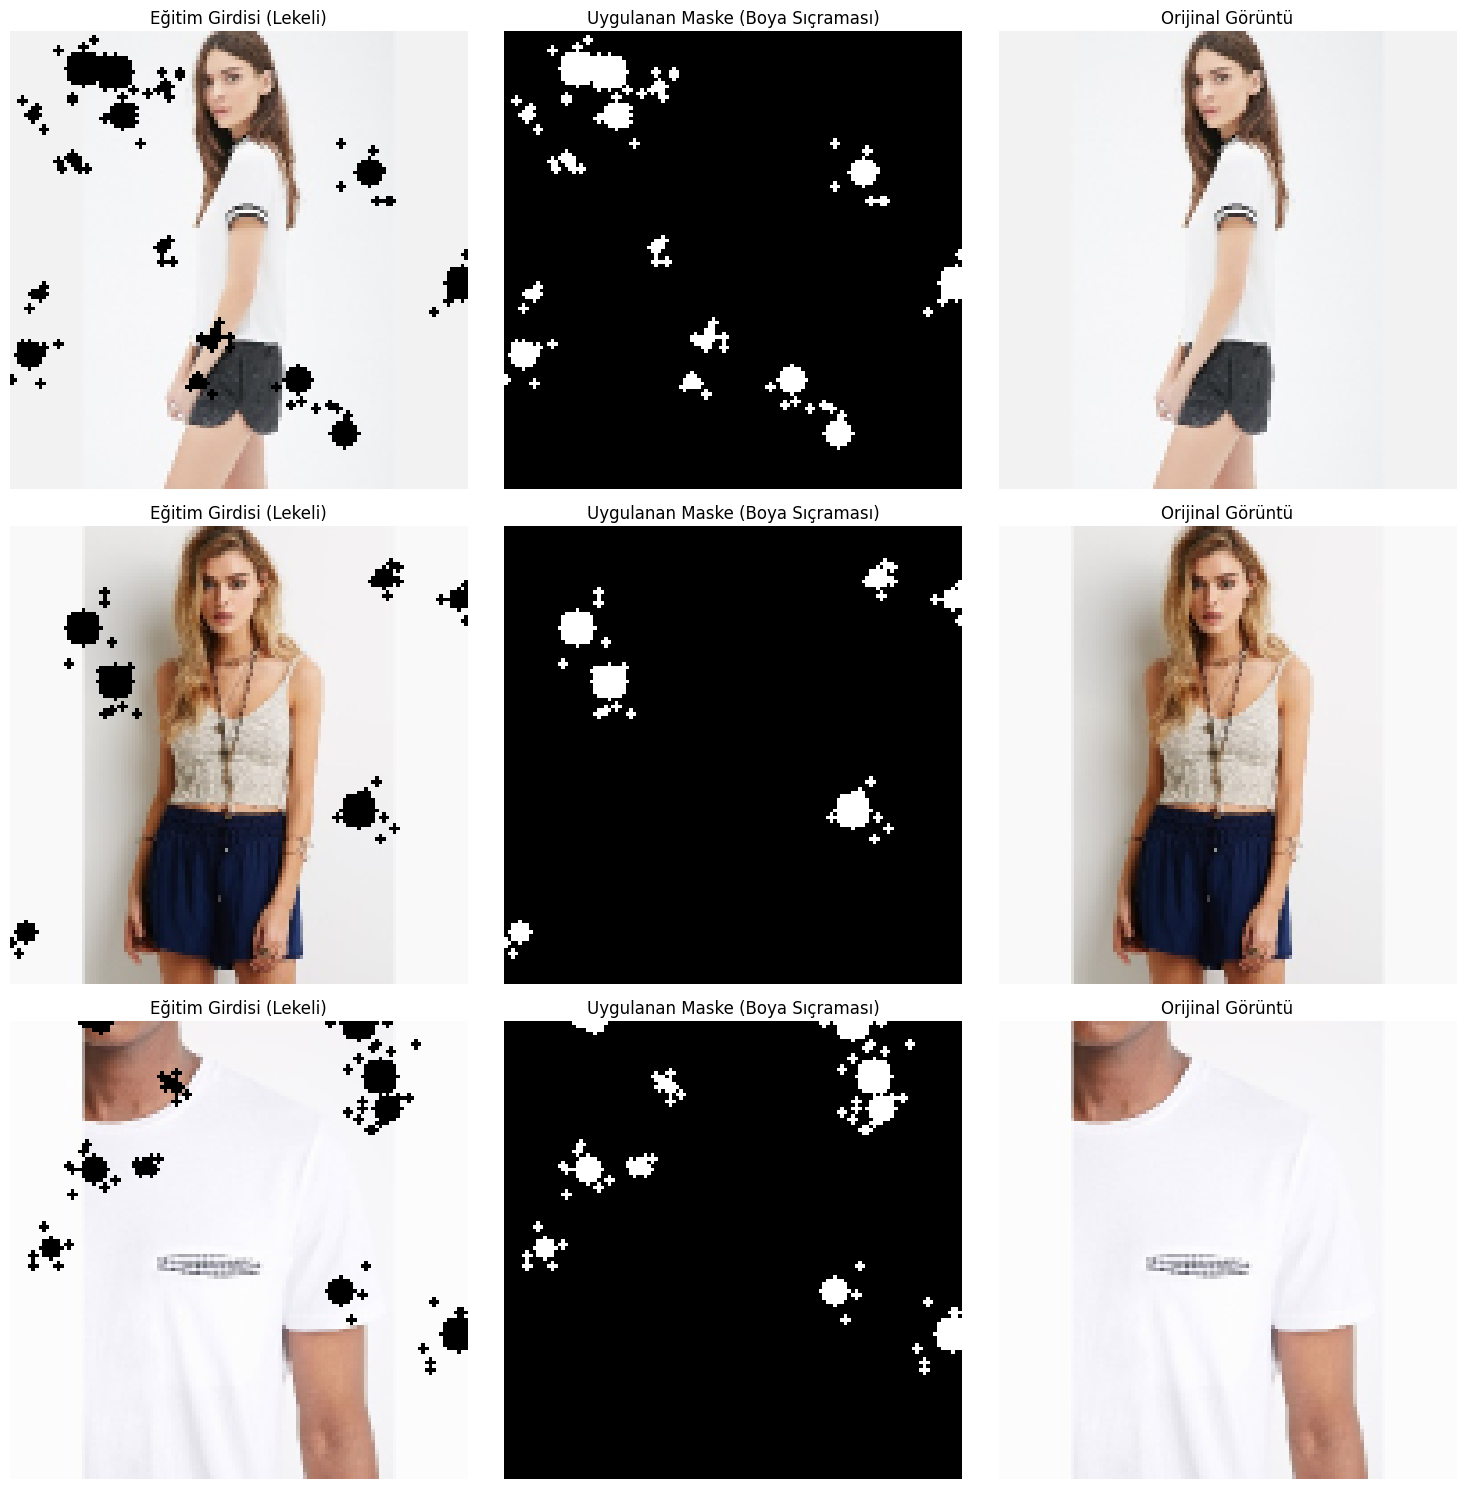

In [ ]:
# VERİ KONTROLÜ (EĞİTİM ÖNCESİ GÖRSELLEŞTİRME)
import matplotlib.pyplot as plt
import numpy as np
import torch

def check_data_augmentation(loader, num_samples=4):
    print("[İŞLEM] Veri yükleyiciden rastgele örnekler çekiliyor...")

    # Dataloader'dan bir batch (grup) veri al
    iter_loader = iter(loader)
    try:
        batch = next(iter_loader)
    except StopIteration:
        iter_loader = iter(loader)
        batch = next(iter_loader)


    masked_imgs = batch['input']
    masks = batch['mask']
    real_imgs = batch['gt']

    # Görselleştirme
    plt.figure(figsize=(15, 5 * num_samples))

    for i in range(num_samples):
        # Tensörleri (C, H, W) -> Numpy (H, W, C) formatına çevir
        # .permute(1, 2, 0) kanalları en sona alır
        img_in = masked_imgs[i].permute(1, 2, 0).numpy()
        mask_in = masks[i].permute(1, 2, 0).numpy()
        img_gt = real_imgs[i].permute(1, 2, 0).numpy()

        # 1. Lekeli Görüntü (Modelin Gireceği Veri)
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(np.clip(img_in, 0, 1))
        plt.title("Eğitim Girdisi (Lekeli)")
        plt.axis('off')

        # 2. Üretilen Maske (Modelin Bulması Gereken Yer)
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(mask_in.squeeze(), cmap='gray', vmin=0, vmax=1)
        plt.title("Uygulanan Maske (Boya Sıçraması)")
        plt.axis('off')

        # 3. Orijinal Görüntü (Hedef)
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(np.clip(img_gt, 0, 1))
        plt.title("Orijinal Görüntü")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Fonksiyonu eğitim veri setinden örneklerle çalıştır
print("[BİLGİ] Rastgele boya sıçraması örnekleri gösteriliyor...")
check_data_augmentation(dataloader, num_samples=3)

# Önerilen Model Mimarisi (Mask Guided HAT)

In [ ]:
# MODEL MİMARİSİ
import os
import sys
import torch.nn as nn
import torchvision.transforms.functional as F

# --- DÜZELTME 1: TORCHVISION UYUMSUZLUĞU ---
# Yeni torchvision sürümlerinde kaldırılan modülü yamalıyoruz
try:
    import torchvision.transforms.functional_tensor
except ImportError:

    sys.modules['torchvision.transforms.functional_tensor'] = F

# --- DÜZELTME 2: REGISTRY ÇAKIŞMASI ---
# "HAT already registered" hatasını önlemek için kayıt defterini temizliyoruz
try:
    from basicsr.utils.registry import ARCH_REGISTRY
    # Eğer kayıt defteri varsa içini boşaltıyoruz
    if hasattr(ARCH_REGISTRY, '_obj_map'):
        ARCH_REGISTRY._obj_map.clear()
        print("[BAKIM] Model kayıt defteri temizlendi.")
except ImportError:
    pass

# --- DÜZELTME 3: HATALI DOSYA TEMİZLİĞİ ---
problematic_file = '/content/HAT/hat/data/imagenet_paired_dataset.py'
if os.path.exists(problematic_file):
    os.remove(problematic_file)

# --- MODEL İMPORT İŞLEMİ ---
try:
    from hat.archs.hat_arch import HAT as OriginalHAT
except ImportError:
    sys.path.append('/content/HAT/hat/archs')
    from hat_arch import HAT as OriginalHAT

# --- MODEL SINIFI ---
class MaskGuidedHAT(nn.Module):
    def __init__(self, img_size=128):
        super(MaskGuidedHAT, self).__init__()

        # 1. Kodlayıcı Omurga (Backbone): HAT
        self.hat = OriginalHAT(img_size=img_size, embed_dim=180, upscale=1, window_size=8)
        if hasattr(self.hat, 'conv_last'): del self.hat.conv_last

        # 2. Segmentasyon Bloğu (Leke Tespiti)
        self.seg_head = nn.Sequential(
            nn.Conv2d(180, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 1, 1) # Çıktı: Logits
        )

        # 3. Restorasyon Bloğu (Leke Temizleme)
        self.inpaint_head = nn.Sequential(
            nn.Conv2d(181, 128, 3, 1, 1), # Girdi: 180 özellik + 1 maske kanalı
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 3, 3, 1, 1),
            nn.Sigmoid() # Çıktı: 0-1 aralığında RGB görüntü
        )

    def forward_backbone(self, x):
        # HAT mimarisinin ileri besleme işlemleri
        x = self.hat.conv_first(x)
        shortcut = x
        if hasattr(self.hat, 'patch_embed'): x = self.hat.patch_embed(x)
        if hasattr(self.hat, 'layers'):
            # Dinamik boyut kontrolü
            x_size = (x.size(2), x.size(3)) if x.dim() == 4 else (int(x.size(1)**0.5), int(x.size(1)**0.5))
            rpi_sa = getattr(self.hat, 'relative_position_index_SA', None)
            rpi_oca = getattr(self.hat, 'relative_position_index_OCA', None)
            params = {'rpi_sa': rpi_sa, 'rpi_oca': rpi_oca, 'attn_mask': None}
            for layer in self.hat.layers:
                try: x = layer(x, x_size, params)
                except: x = layer(x, x_size)
        if hasattr(self.hat, 'norm'): x = self.hat.norm(x)
        if hasattr(self.hat, 'patch_unembed'): x = self.hat.patch_unembed(x, x_size)
        x = self.hat.conv_after_body(x)
        x = x + shortcut
        return x

    def forward(self, x):
        # Öznitelik Çıkarımı
        feat = self.forward_backbone(x)

        # Adım 1: Segmentasyon
        mask_logits = self.seg_head(feat)
        mask_probs = torch.sigmoid(mask_logits)

        # Adım 2: Restorasyon
        combined = torch.cat([feat, mask_probs], dim=1)
        restored_img = self.inpaint_head(combined)

        return mask_logits, restored_img

# Modelin GPU'ya yüklenmesi
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MaskGuidedHAT(img_size=128).to(device)
print("[DURUM] Model başarıyla başlatıldı (Hatalar giderildi).")

[BAKIM] Model kayıt defteri temizlendi.


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[DURUM] Model başarıyla başlatıldı (Hatalar giderildi).


# ikinci model

In [12]:
# MODEL MİMARİSİ (GÜNCELLENMİŞ - ASPP/Mask R-CNN Mantığı ile)
import os
import sys
import torch
import torch.nn as nn
import torchvision.transforms.functional as F

# --- DÜZELTME 1: TORCHVISION UYUMSUZLUĞU ---
# Yeni torchvision sürümlerinde kaldırılan modülü yamalıyoruz
try:
    import torchvision.transforms.functional_tensor
except ImportError:
    sys.modules['torchvision.transforms.functional_tensor'] = F

# --- DÜZELTME 2: REGISTRY ÇAKIŞMASI ---
# "HAT already registered" hatasını önlemek için kayıt defterini temizliyoruz
try:
    from basicsr.utils.registry import ARCH_REGISTRY
    if hasattr(ARCH_REGISTRY, '_obj_map'):
        ARCH_REGISTRY._obj_map.clear()
        print("[BAKIM] Model kayıt defteri temizlendi.")
except ImportError:
    pass

# --- DÜZELTME 3: HATALI DOSYA TEMİZLİĞİ ---
problematic_file = '/content/HAT/hat/data/imagenet_paired_dataset.py'
if os.path.exists(problematic_file):
    os.remove(problematic_file)

# --- MODEL IMPORT İŞLEMİ (Eksik olan kısım buydu!) ---
try:
    from hat.archs.hat_arch import HAT as OriginalHAT
except ImportError:
    sys.path.append('/content/HAT/hat/archs')
    from hat_arch import HAT as OriginalHAT


# --- YENİ EKLENEN GELİŞMİŞ SEGMENTASYON MODÜLÜ (ASPP) ---
class AdvancedSegHead(nn.Module):
    """
    Farklı boyutlardaki lekeleri yakalamak için Mask R-CNN ve DeepLab
    gibi modellerde kullanılan ASPP (Genişletilmiş Evrişim) mantığı.
    """
    def __init__(self, in_channels=180, mid_channels=64):
        super(AdvancedSegHead, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=1)
        self.conv2 = nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=2, dilation=2)
        self.conv3 = nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=4, dilation=4)

        self.bn = nn.BatchNorm2d(mid_channels * 3)
        self.relu = nn.ReLU(inplace=True)
        self.out_conv = nn.Conv2d(mid_channels * 3, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(x)
        x3 = self.conv3(x)

        out = torch.cat([x1, x2, x3], dim=1)
        out = self.relu(self.bn(out))
        return self.out_conv(out)


# --- MODEL SINIFI ---
class MaskGuidedHAT(nn.Module):
    def __init__(self, img_size=128):
        super(MaskGuidedHAT, self).__init__()

        # 1. Kodlayıcı Omurga (Backbone): HAT
        self.hat = OriginalHAT(img_size=img_size, embed_dim=180, upscale=1, window_size=8)
        if hasattr(self.hat, 'conv_last'): del self.hat.conv_last

        # 2. Segmentasyon Bloğu (Leke Tespiti - GÜNCELLENDİ)
        self.seg_head = AdvancedSegHead(in_channels=180, mid_channels=64)

        # 3. Restorasyon Bloğu (Leke Temizleme)
        self.inpaint_head = nn.Sequential(
            nn.Conv2d(181, 128, 3, 1, 1), # Girdi: 180 özellik + 1 maske kanalı
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 3, 3, 1, 1),
            nn.Sigmoid() # Çıktı: 0-1 aralığında RGB görüntü
        )

    def forward_backbone(self, x):
        x = self.hat.conv_first(x)
        shortcut = x
        if hasattr(self.hat, 'patch_embed'): x = self.hat.patch_embed(x)
        if hasattr(self.hat, 'layers'):
            x_size = (x.size(2), x.size(3)) if x.dim() == 4 else (int(x.size(1)**0.5), int(x.size(1)**0.5))
            rpi_sa = getattr(self.hat, 'relative_position_index_SA', None)
            rpi_oca = getattr(self.hat, 'relative_position_index_OCA', None)
            params = {'rpi_sa': rpi_sa, 'rpi_oca': rpi_oca, 'attn_mask': None}
            for layer in self.hat.layers:
                try: x = layer(x, x_size, params)
                except: x = layer(x, x_size)
        if hasattr(self.hat, 'norm'): x = self.hat.norm(x)
        if hasattr(self.hat, 'patch_unembed'): x = self.hat.patch_unembed(x, x_size)
        x = self.hat.conv_after_body(x)
        x = x + shortcut
        return x

    def forward(self, x):
        feat = self.forward_backbone(x)
        mask_logits = self.seg_head(feat)
        mask_probs = torch.sigmoid(mask_logits)
        combined = torch.cat([feat, mask_probs], dim=1)
        restored_img = self.inpaint_head(combined)
        return mask_logits, restored_img

print("[BİLGİ] Gelişmiş MaskGuidedHAT mimarisi tanımlandı.")

[BAKIM] Model kayıt defteri temizlendi.
[BİLGİ] Gelişmiş MaskGuidedHAT mimarisi tanımlandı.


# Hiperparametreler ve Kayıp Fonksiyonları

In [13]:
# EĞİTİM KONFİGÜRASYONU (A100 OPTİMİZASYONU VE GELİŞMİŞ SEGMENTASYON)
import torch
import torch.nn as nn
import torchvision.models as models
from hat.archs.discriminator_arch import UNetDiscriminatorSN
from torch.utils.data import DataLoader

NUM_EPOCHS = 10
BATCH_SIZE = 16
LR = 1e-4

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
dataloader = train_dataloader # Ana döngü için atama

# --- YENİ: BİRLEŞTİRİLMİŞ GELİŞMİŞ SEGMENTASYON KAYBI (BCE + DICE) ---
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        # 1. Klasik BCE (Piksel bazlı doğruluk)
        bce_loss = self.bce(logits, targets)

        # 2. Dice Loss (Bölgesel örtüşme ve keskin sınırlar için)
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_loss = 1.0 - (2.0 * intersection + 1e-7) / (union + 1e-7)

        # İki kaybın toplamını döndür
        return bce_loss + dice_loss.mean()

# Kayıp Fonksiyonları
criterion_l1 = nn.L1Loss()
# Eğitim döngün bozulmasın diye değişken adını aynı tuttuk ama içi artık çok daha güçlü!
criterion_bce = BCEDiceLoss()

# VGG Ağı (Algısal Kayıp için - Dondurulmuş ağırlıklar)
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features[:35].eval().to(device)
for p in vgg.parameters(): p.requires_grad = False

# Discriminator (Ayırt Edici Ağ)
discriminator = UNetDiscriminatorSN(num_in_ch=3).to(device)

model = MaskGuidedHAT(img_size=128).to(device)
print("[DURUM] Yeni nesil MaskGuidedHAT modeli başarıyla başlatıldı.")

# Optimizasyon
optimizer_G = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))

# Karma Hassasiyet (AMP) Hızlandırıcı
scaler = torch.cuda.amp.GradScaler()

print(f"[BİLGİ] Eğitim konfigürasyonu A100 GPU ve Gelişmiş Segmentasyon (BCE+Dice) için ayarlandı. Batch Size: {BATCH_SIZE}")

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[DURUM] Yeni nesil MaskGuidedHAT modeli başarıyla başlatıldı.
[BİLGİ] Eğitim konfigürasyonu A100 GPU ve Gelişmiş Segmentasyon (BCE+Dice) için ayarlandı. Batch Size: 16


/tmp/ipykernel_668/351425187.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


# Training

In [15]:
# EĞİTİM DÖNGÜSÜ
import torch
import gc
import torch.nn.functional as F
import os

# --- DRIVE KAYIT KLASÖRÜ HAZIRLIĞI ---
kayit_klasoru = "/content/drive/MyDrive/Goruntu_Analizi_Projesi/Modeller"
os.makedirs(kayit_klasoru, exist_ok=True)
print(f"[BİLGİ] Modeller Drive'da şu konuma kaydedilecek: {kayit_klasoru}")

# --- BELLEK TEMİZLİĞİ ---
print("GPU Belleği temizleniyor...")
gc.collect()
torch.cuda.empty_cache()
print("-" * 30)

print(f"\n[BAŞLANGIÇ] Eğitim {NUM_EPOCHS} Epoch boyunca başlıyor...")

# En iyi kaybı takip etmek için başlangıç değeri (Sonsuz)
best_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss_g = 0

    for i, batch in enumerate(dataloader):
        real = batch['gt'].to(device)
        mask = batch['mask'].to(device)
        masked = batch['input'].to(device)

        # --- Generator Eğitimi ---
        optimizer_G.zero_grad()
        with torch.cuda.amp.autocast():
            p_mask_logits, p_img = model(masked)

            # Toplam Kayıp Hesaplama (Yeni AdvancedSegHead ve BCEDiceLoss ile)
            loss_mask = 10.0 * criterion_bce(p_mask_logits, mask)      # Segmentasyon önceliği
            loss_pix = 1.0 * criterion_l1(p_img, real)                 # Piksel doğruluğu
            loss_perc = 5.0 * criterion_l1(vgg(p_img), vgg(real))      # Doku kalitesi

            # !!! KRİTİK DÜZELTME: GAN Generator kaybında EKSİ işareti olmalı !!!
            loss_adv = -0.1 * torch.mean(discriminator(p_img))         # Gerçekçilik

            loss_G = loss_mask + loss_pix + loss_perc + loss_adv

        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)
        scaler.update()

        # --- Discriminator Eğitimi ---
        optimizer_D.zero_grad()
        with torch.cuda.amp.autocast():
            d_real = discriminator(real)
            d_fake = discriminator(p_img.detach())
            # Hinge Loss
            loss_D = (torch.mean(F.relu(1.0 - d_real)) + torch.mean(F.relu(1.0 + d_fake))) / 2.0

        scaler.scale(loss_D).backward()
        scaler.step(optimizer_D)
        scaler.update()

        total_loss_g += loss_G.item()

        # Loglama sıklığını veri setinin büyüklüğüne göre ayarladım (her 200 adımda bir)
        if i % 200 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Adım {i} | Loss G: {loss_G.item():.4f} | Loss D: {loss_D.item():.4f}")

    avg_loss = total_loss_g / len(dataloader)
    print(f"[TAMAMLANDI] Epoch {epoch+1} Bitti. Ortalama Generator Kaybı: {avg_loss:.4f}")

    # --- MODELİ DRIVE'A KAYDETME İŞLEMİ (ÇÖKMELERE KARŞI ÖNLEM) ---

    # 1. Her epoch sonunda güncel modeli garantilemek için kaydet
    guncel_model_yolu = os.path.join(kayit_klasoru, "guncel_model.pth")
    torch.save(model.state_dict(), guncel_model_yolu)
    print(f" -> [KAYIT] Güncel model Drive'a yedeklendi.")

    # 2. Eğer bu epoch'taki kayıp (loss) rekor kırdıysa, "en iyi" olarak kaydet
    if avg_loss < best_loss:
        best_loss = avg_loss
        en_iyi_model_yolu = os.path.join(kayit_klasoru, "en_iyi_model.pth")
        torch.save(model.state_dict(), en_iyi_model_yolu)
        print(f" -> [BAŞARI] Yeni en iyi model Drive'a kaydedildi! (Kayıp: {best_loss:.4f})")

    print("-" * 60)

# Tüm eğitim sorunsuz bittiğinde son bir kayıt
tamamlanmis_model_yolu = os.path.join(kayit_klasoru, "tamamlanmis_model.pth")
torch.save(model.state_dict(), tamamlanmis_model_yolu)
print("\n[EĞİTİM SONU] Maraton bitti ve son model Drive'a başarıyla kaydedildi!")

[BİLGİ] Modeller Drive'da şu konuma kaydedilecek: /content/drive/MyDrive/Goruntu_Analizi_Projesi/Modeller
GPU Belleği temizleniyor...
------------------------------

[BAŞLANGIÇ] Eğitim 10 Epoch boyunca başlıyor...


/tmp/ipykernel_668/2627973695.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_668/2627973695.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/10] Adım 0 | Loss G: 19.4617 | Loss D: 0.8164
Epoch [1/10] Adım 200 | Loss G: 19.6585 | Loss D: 1.6904
Epoch [1/10] Adım 400 | Loss G: 19.0289 | Loss D: 0.2120
Epoch [1/10] Adım 600 | Loss G: 18.8253 | Loss D: 0.9795
Epoch [1/10] Adım 800 | Loss G: 19.3836 | Loss D: 0.9873
Epoch [1/10] Adım 1000 | Loss G: 17.9712 | Loss D: 0.0178
Epoch [1/10] Adım 1200 | Loss G: 17.4756 | Loss D: 0.2212
Epoch [1/10] Adım 1400 | Loss G: 17.6952 | Loss D: 0.2856
Epoch [1/10] Adım 1600 | Loss G: 16.9825 | Loss D: 0.2462
Epoch [1/10] Adım 1800 | Loss G: 16.2781 | Loss D: 0.2600
Epoch [1/10] Adım 2000 | Loss G: 15.9178 | Loss D: 0.6831
Epoch [1/10] Adım 2200 | Loss G: 11.4505 | Loss D: 0.9561
Epoch [1/10] Adım 2400 | Loss G: 9.9438 | Loss D: 0.9072
Epoch [1/10] Adım 2600 | Loss G: 10.3547 | Loss D: 0.9463
Epoch [1/10] Adım 2800 | Loss G: 9.5157 | Loss D: 0.8574
[TAMAMLANDI] Epoch 1 Bitti. Ortalama Generator Kaybı: 15.8574
 -> [KAYIT] Güncel model Drive'a yedeklendi.
 -> [BAŞARI] Yeni en iyi model D

In [16]:
# ==============================================================================
# DİKKAT: YENİ BİR OTURUMDA BU HÜCREYİ ÇALIŞTIRMADAN ÖNCE ŞU HÜCRELERİ ÇALIŞTIR:
# 1. Ortam Kurulumu
# 2. Model Mimarisi - Mask Guided HAT (Gelişmiş Segmentasyonlu Yeni Versiyon)
# ==============================================================================

import torch
import os

print("[BİLGİ] Test aşaması başlatılıyor. Model Drive'dan yükleniyor...")

# Cihaz ayarı (GPU varsa GPU, yoksa CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Modeli oluştur (Ağırlıkları yükleyebilmek için iskelete ihtiyacımız var)
# NOT: Hafızadaki bu iskelet artık yeni AdvancedSegHead'i içeriyor!
test_model = MaskGuidedHAT(img_size=128).to(device)

# Drive'daki en iyi modelin yolu
model_yolu = "/content/drive/MyDrive/Goruntu_Analizi_Projesi/Modeller/en_iyi_model.pth"

if os.path.exists(model_yolu):
    try:
        # Model ağırlıklarını yükle
        test_model.load_state_dict(torch.load(model_yolu, map_location=device))
        test_model.eval() # Modeli test (değerlendirme) moduna alıyoruz
        print(f"[BAŞARILI] Model ağırlıkları başarıyla yüklendi!\nYol: {model_yolu}")

    except RuntimeError as e:
        print("\n[HATA] Ağırlıklar yüklenirken bir uyumsuzluk yaşandı!")
        print("Muhtemel Sebep: Eski mimariyle (basit seg_head) eğitilmiş bir modeli, yeni gelişmiş mimariye (AdvancedSegHead) yüklemeye çalışıyorsunuz.")
        print("Çözüm: Yeni mimariyle modeli en az 1 epoch eğitip, Drive'a yeni formatta bir 'en_iyi_model.pth' kaydetmesini sağlamalısınız.")
        # print(f"Hata Detayı: {e}") # Hata detayını görmek istersen başındaki diyezi kaldırabilirsin
else:
    print(f"[HATA] Model dosyası bulunamadı! Lütfen yolun doğru olduğundan emin olun:\n{model_yolu}")

[BİLGİ] Test aşaması başlatılıyor. Model Drive'dan yükleniyor...
[BAŞARILI] Model ağırlıkları başarıyla yüklendi!
Yol: /content/drive/MyDrive/Goruntu_Analizi_Projesi/Modeller/en_iyi_model.pth


[İŞLEM] Belirtilen indekslerdeki görüntüler test ediliyor...


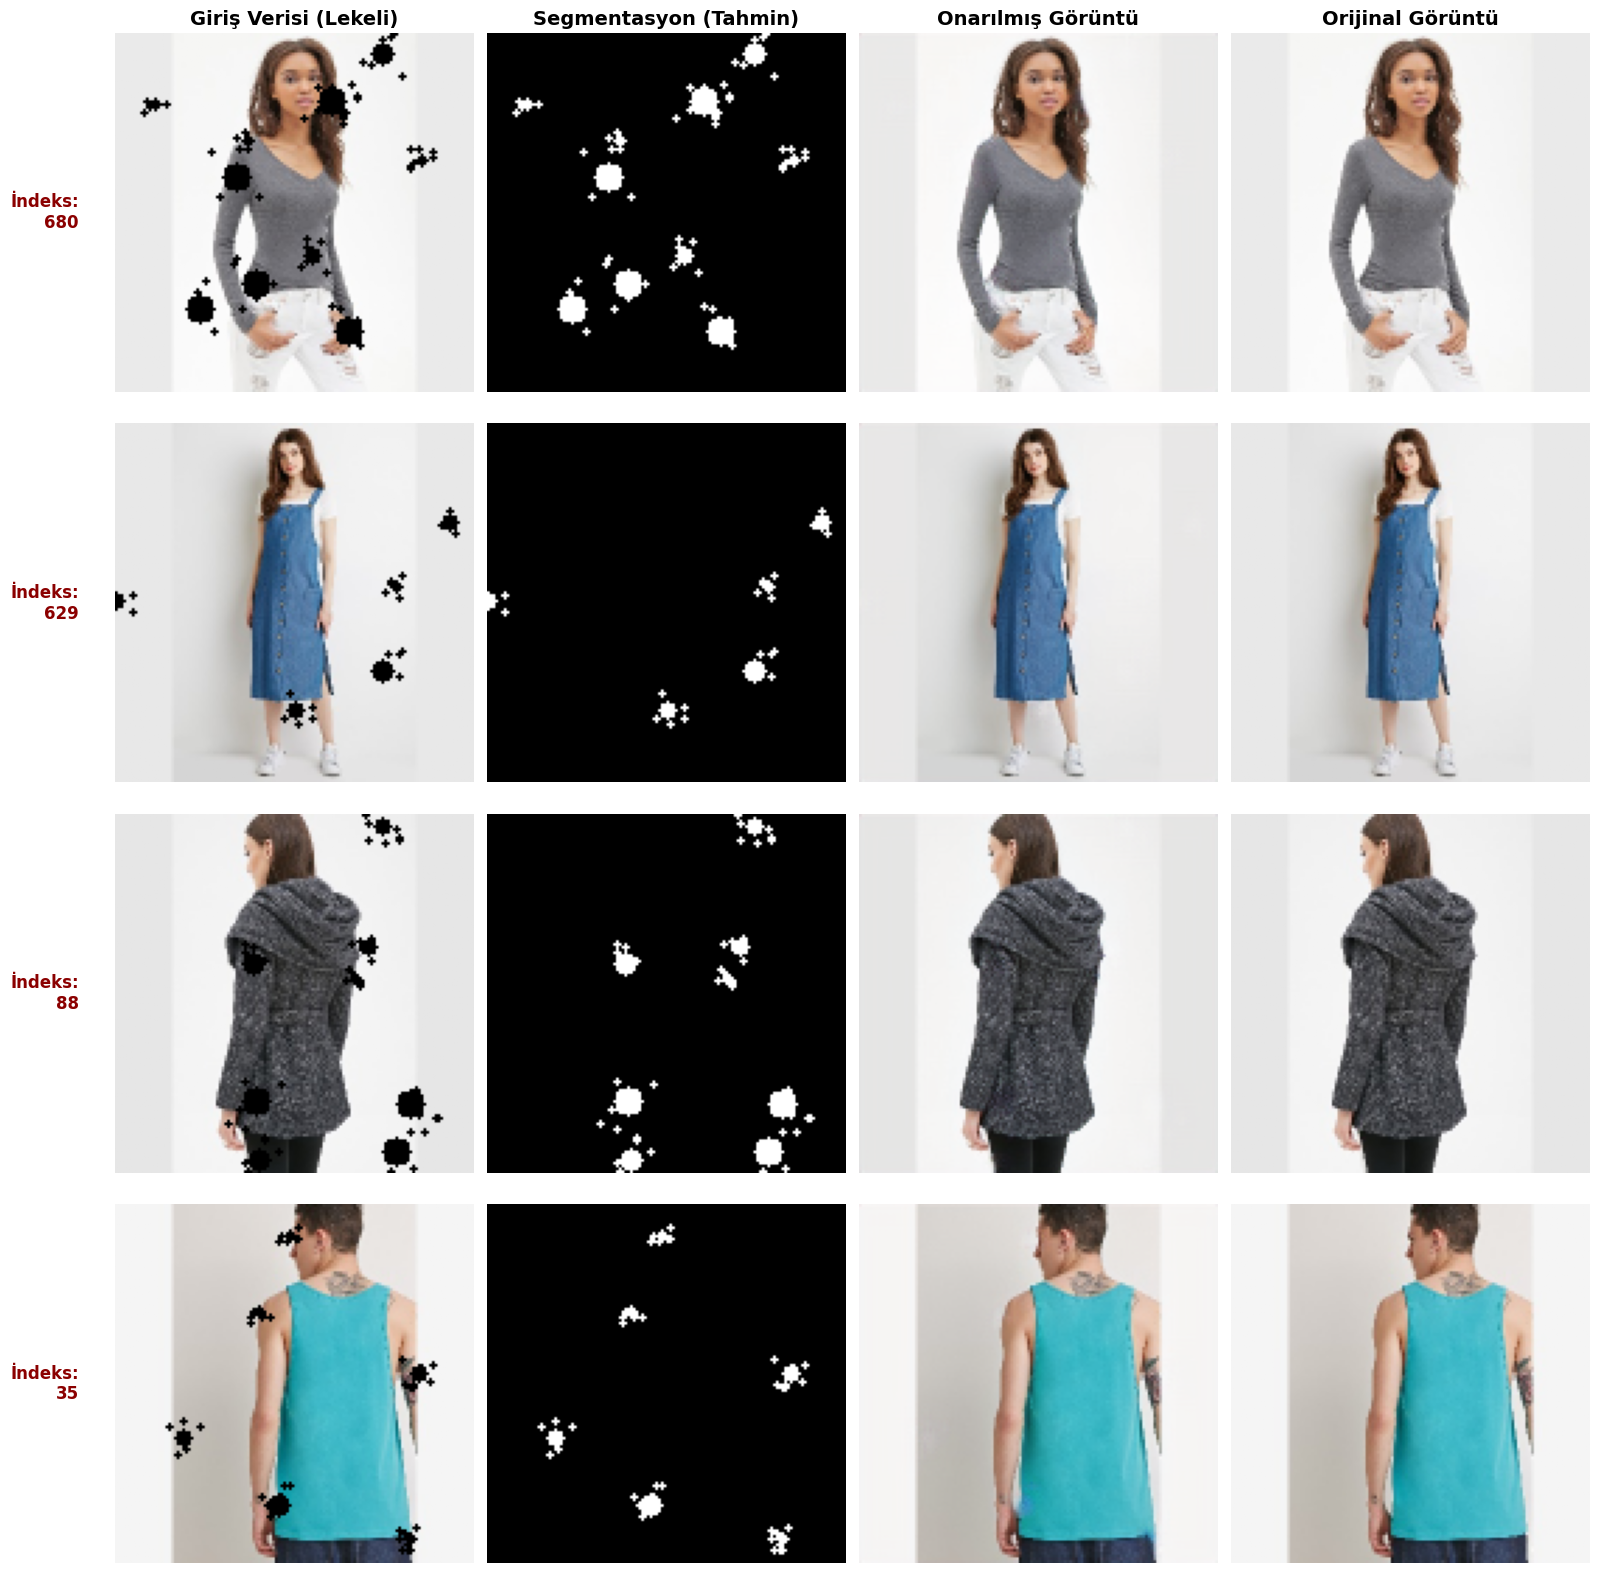

In [17]:
# ==============================================================================
# DİKKAT: YENİ BİR OTURUMDA BU HÜCREYİ ÇALIŞTIRMADAN ÖNCE ŞU HÜCRELERİ ÇALIŞTIRIN:
# 1. Veri Setinin Hazırlanması
# 2. Veri Yükleme ve Dataloader
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import torch

print("[İŞLEM] Belirtilen indekslerdeki görüntüler test ediliyor...")

# Senin incelemek istediğin spesifik görüntü sıraları (indeksler)
secilen_indeksler = [680, 629, 88, 35]

# Seçilen indekslerdeki verileri toplayıp yapay bir "batch" (grup) oluşturacağız
inputs_list = []
gt_masks_list = []
gt_imgs_list = []

for idx in secilen_indeksler:
    # İstenen indeksin test setinin boyutlarını aşıp aşmadığını kontrol et
    if idx >= len(test_dataset):
        print(f"[HATA] {idx}. sıra test veri setinde yok! (Maksimum sınır: {len(test_dataset)-1})")
        continue

    # Doğrudan test_dataset'in o sırasındaki sözlüğü (dictionary) alıyoruz
    ornek = test_dataset[idx]

    inputs_list.append(ornek['input'])
    gt_masks_list.append(ornek['mask'])
    gt_imgs_list.append(ornek['gt'])

# Eğer geçerli indeksler bulunduysa işlemlere devam et
if len(inputs_list) > 0:
    # Listeleri PyTorch tensörüne çevirip tek bir "batch" yapıyoruz ve GPU'ya yolluyoruz
    inputs = torch.stack(inputs_list).to(device)
    gt_masks = torch.stack(gt_masks_list).to(device)
    gt_imgs = torch.stack(gt_imgs_list).to(device)

    # Modelden tahmin alma (Gradients hesaplamaya gerek yok)
    with torch.no_grad():
        mask_logits, restored_imgs = test_model(inputs)
        # Logits değerlerini 0-1 arası olasılıklara çeviriyoruz
        pred_masks_probs = torch.sigmoid(mask_logits)

    # Görselleştirme için dinamik boyutlu figür oluştur (4 sütun, kaç resim varsa o kadar satır)
    fig, axes = plt.subplots(len(inputs_list), 4, figsize=(16, 4 * len(inputs_list)))
    basliklar = ["Giriş Verisi (Lekeli)", "Segmentasyon (Tahmin)", "Onarılmış Görüntü", "Orijinal Görüntü"]

    for i in range(len(inputs_list)):
        # PyTorch tensörlerini (C, H, W) Numpy dizilerine (H, W, C) çevirip CPU'ya alıyoruz
        img_in = inputs[i].permute(1, 2, 0).cpu().numpy()

        # Maske tek kanallı olduğu için squeeze yapıyoruz
        mask_pred = pred_masks_probs[i].squeeze().cpu().numpy()
        mask_pred_binary = (mask_pred > 0.5).astype(np.float32) # İkili maskeye çevirme

        img_restored = restored_imgs[i].permute(1, 2, 0).cpu().numpy()
        img_gt = gt_imgs[i].permute(1, 2, 0).cpu().numpy()

        gorseller = [img_in, mask_pred_binary, img_restored, img_gt]

        for j in range(4):
            # Eğer sadece 1 resim varsa `axes` tek boyutlu olur, hata almamak için kontrol
            ax = axes[i, j] if len(inputs_list) > 1 else axes[j]

            # Segmentasyon maskesi için gri tonlama
            cmap_val = 'gray' if j == 1 else None

            # Değerleri 0-1 aralığında tutarak çizdiriyoruz
            ax.imshow(np.clip(gorseller[j], 0, 1), cmap=cmap_val)
            ax.axis('off')

            # Başlıkları sadece en üst satıra yaz
            if i == 0:
                ax.set_title(basliklar[j], fontsize=14, fontweight='bold')

            # Her satırın en soluna, hangi indeksi test ettiğimizi yazdıralım
            if j == 0:
                ax.text(-0.1, 0.5, f"İndeks:\n{secilen_indeksler[i]}",
                        va='center', ha='right', transform=ax.transAxes,
                        fontsize=12, fontweight='bold', color='darkred')

    plt.tight_layout()
    plt.show()
else:
    print("[HATA] Görselleştirilecek geçerli bir indeks bulunamadı.")

In [18]:
# SEGMENTASYON METRİKLERİ (GPU Hızlandırmalı)
import torch

print("[İŞLEM] Tüm test seti üzerinden Segmentasyon Metrikleri hesaplanıyor...\n")

toplam_iou = 0.0
toplam_dice = 0.0
toplam_acc = 0.0
ornek_sayisi = 0

# Modelin kesinlikle değerlendirme modunda olduğundan emin oluyoruz (Dropout vb. kapanır)
test_model.eval()

with torch.no_grad():
    for batch in test_dataloader:
        # Verileri GPU'ya alıyoruz
        inputs = batch['input'].to(device)
        gt_masks = batch['mask'].to(device) # Gerçek maskeler GPU'da kalıyor

        # Model tahmini
        mask_logits, _ = test_model(inputs)
        pred_masks_probs = torch.sigmoid(mask_logits)

        # Olasılıkları 0 ve 1'lerden oluşan tahmin maskelerine çevir (Doğrudan GPU üzerinde)
        pred_masks_binary = (pred_masks_probs > 0.5).float()
        gt_masks_float = gt_masks.float()

        # Batch içindeki her bir görsel için hesaplama
        for i in range(inputs.size(0)):
            y_true = gt_masks_float[i].squeeze()
            y_pred = pred_masks_binary[i].squeeze()

            # --- GPU Üzerinde Hızlı Tensör Matematiği ---
            kesisim = torch.sum(y_true * y_pred).item()
            toplam_y_true = torch.sum(y_true).item()
            toplam_y_pred = torch.sum(y_pred).item()

            birlesim = toplam_y_true + toplam_y_pred - kesisim

            # IoU
            iou = kesisim / (birlesim + 1e-7)

            # Dice
            dice = (2. * kesisim) / (toplam_y_true + toplam_y_pred + 1e-7)

            # Piksel Doğruluğu
            acc = torch.mean((y_true == y_pred).float()).item()

            # Toplamlara ekle
            toplam_iou += iou
            toplam_dice += dice
            toplam_acc += acc
            ornek_sayisi += 1

print("="*40)
print("SEGMENTASYON METRİKLERİ (Tüm Test Seti)")
print("="*40)
print(f"Ortalama IoU              : {toplam_iou / ornek_sayisi:.4f}")
print(f"Ortalama Dice Katsayısı   : {toplam_dice / ornek_sayisi:.4f}")
print(f"Ortalama Piksel Doğruluğu : {toplam_acc / ornek_sayisi:.4f}")
print("="*40)

[İŞLEM] Tüm test seti üzerinden Segmentasyon Metrikleri hesaplanıyor...

SEGMENTASYON METRİKLERİ (Tüm Test Seti)
Ortalama IoU              : 1.0000
Ortalama Dice Katsayısı   : 1.0000
Ortalama Piksel Doğruluğu : 1.0000


In [19]:
# RESTORASYON METRİKLERİ HESAPLAMA (GPU Optimizasyonlu)
import torch
import torch.nn.functional as F
import numpy as np
from skimage.metrics import structural_similarity as ssim
# psnr importuna gerek kalmadı, inanılmaz hızlı bir şekilde GPU'da hesaplayacağız

print("[İŞLEM] Tüm test seti üzerinden Restorasyon Metrikleri hesaplanıyor...\n")

toplam_psnr = 0.0
toplam_ssim = 0.0
toplam_mse = 0.0
ornek_sayisi = 0

# Modelin değerlendirme modunda olduğundan emin oluyoruz
test_model.eval()

with torch.no_grad():
    for batch in test_dataloader:
        inputs = batch['input'].to(device)
        gt_imgs = batch['gt'].to(device) # Gerçek temiz görüntüleri GPU'da tutuyoruz

        # Model tahmini
        _, restored_imgs = test_model(inputs)

        # --- KRİTİK GÜNCELLEME: Çıktıları 0-1 aralığına sıkıştırıyoruz ---
        # Renk değerlerinin 0'ın altına inmesini veya 1'in üstüne çıkmasını engeller.
        # Bu işlem restorasyon metriklerinin matematiksel olarak çökmesini önler.
        restored_imgs = torch.clamp(restored_imgs, 0.0, 1.0)

        for i in range(inputs.size(0)):
            y_true_gpu = gt_imgs[i]
            y_pred_gpu = restored_imgs[i]

            # ==========================================================
            # 1. GPU ÜZERİNDE HIZLI HESAPLAMALAR (MSE ve PSNR)
            # ==========================================================
            mse_gpu = F.mse_loss(y_pred_gpu, y_true_gpu)
            mse_degeri = mse_gpu.item()

            # PSNR Formülü: 10 * log10(MAX^2 / MSE) (MAX değerimiz 1.0 olduğu için 1.0 yazarız)
            if mse_degeri == 0:
                psnr_degeri = 100.0 # İki resim birebir aynıysa sıfıra bölme hatasını engellemek için
            else:
                psnr_degeri = 10.0 * torch.log10(1.0 / mse_gpu).item()

            # ==========================================================
            # 2. CPU ÜZERİNDE HESAPLAMA (Sadece SSIM için)
            # ==========================================================
            # Sadece SSIM hesabı için veriyi Numpy'a ve (H, W, C) formatına geçiriyoruz
            gercek = y_true_gpu.permute(1, 2, 0).cpu().numpy()
            tahmin = y_pred_gpu.permute(1, 2, 0).cpu().numpy()

            ssim_degeri = ssim(gercek, tahmin, data_range=1.0, channel_axis=-1)

            # Toplamlara ekleme
            toplam_mse += mse_degeri
            toplam_psnr += psnr_degeri
            toplam_ssim += ssim_degeri
            ornek_sayisi += 1

print("="*40)
print("RESTORASYON METRİKLERİ (Tüm Test Seti)")
print("="*40)
print(f"Ortalama PSNR : {toplam_psnr / ornek_sayisi:.4f} dB")
print(f"Ortalama SSIM : {toplam_ssim / ornek_sayisi:.4f}")
print(f"Ortalama MSE  : {toplam_mse / ornek_sayisi:.6f}")
print("="*40)

[İŞLEM] Tüm test seti üzerinden Restorasyon Metrikleri hesaplanıyor...

RESTORASYON METRİKLERİ (Tüm Test Seti)
Ortalama PSNR : 39.3443 dB
Ortalama SSIM : 0.9930
Ortalama MSE  : 0.000163
